In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

# Approximate the indtencity distribution by a function $$ a1+a2*x+a3*x^2 + b1*cos(c1+c2*x) $$
# using scipy function "curve_fit" for determination of coefficients


# Koeffitient "c2" is the frequency of the signal we need to find.

In [17]:
from scipy.optimize import curve_fit

In [47]:
def func(x, a1,a2,a3,b1,c1,c2):
    return a1+a2*x+a3*x**2 + b1*np.cos(c1+c2*x)

In [48]:
popt, pcov = curve_fit(func, dist, line)
print(popt)

[ 8.48506958e+01  6.46410846e-01 -7.35757568e-03  6.19203843e+00
 -1.47434716e-01  1.09015736e+00]


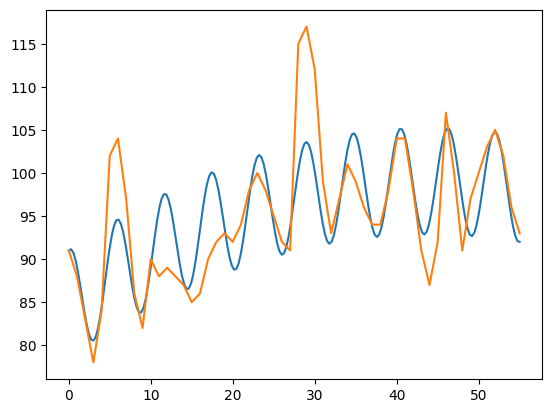

In [49]:
dist_fit = np.linspace(0,55,200)
line_fit = func(dist_fit, *popt)

plt.figure()
plt.plot(dist_fit, line_fit, dist, line)
plt.show()

## Now let's find the frequency of the signal by using phase unwrapping with pre-filtration


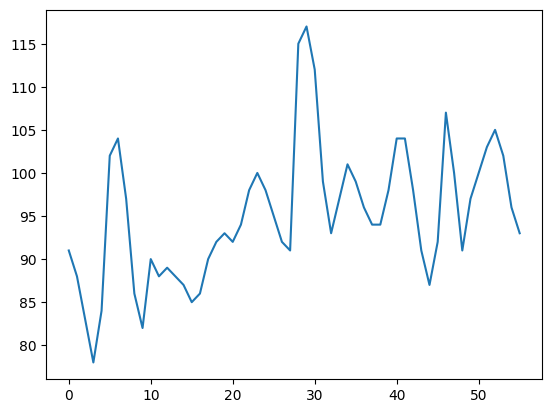

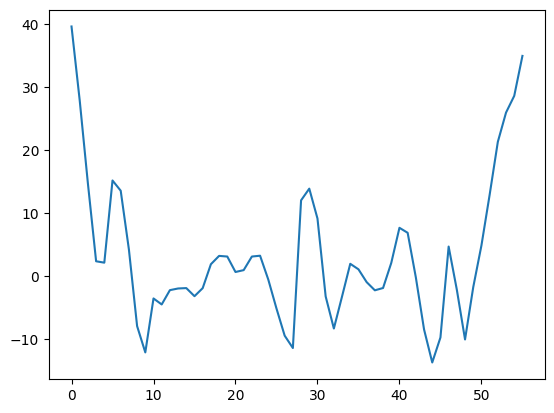

8


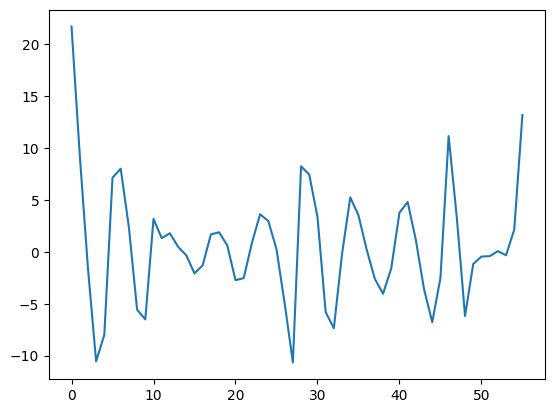

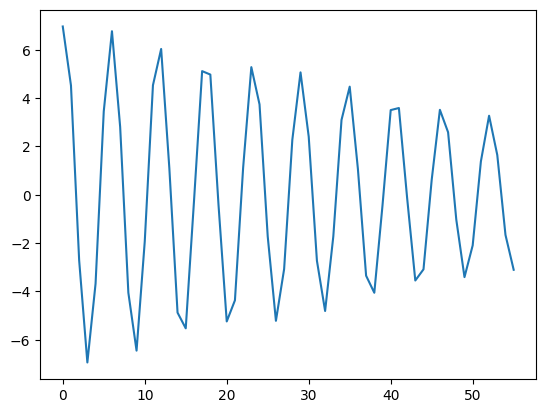

1.0897607487744378


In [67]:
fringe = Fringe(signal = line, fs = 1)
fringe.plot()
fringe.filter_low_frq(nl=3)
fringe.plot()
peak_count = fringe.count_peaks_of_autocorr()
print(peak_count)
fringe.filter_low_frq(nl=peak_count)
fringe.plot()
fringe.update_Wn(rel_h=0.5)
fringe.filter_notch_Wn()
fringe.plot()
frq = fringe.get_frq()
print(frq)

## Testing how selection classes from "generate_areas.py" work

In [3]:
dir_name = 'drop-211025-2'
img_path = 'drop-211025-2/drop-0080.jpg'

In [24]:
select = ga.SelectRNDArea(img_path)

In [26]:
lp = select.get_random_rois(num=20)

In [27]:
lines = select.lines_from_img()

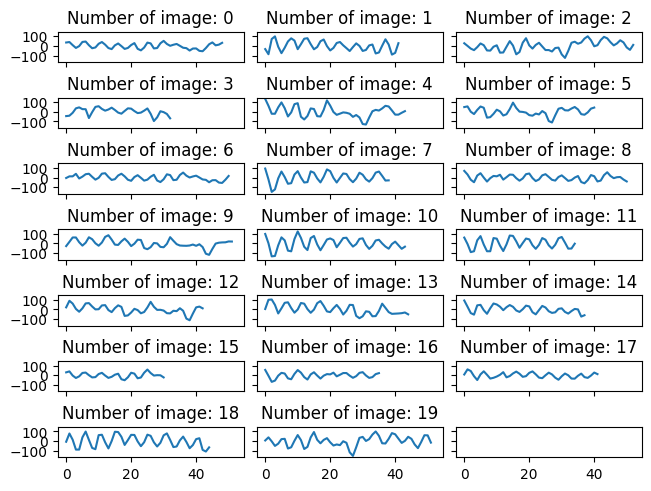

In [28]:
lines.plot()

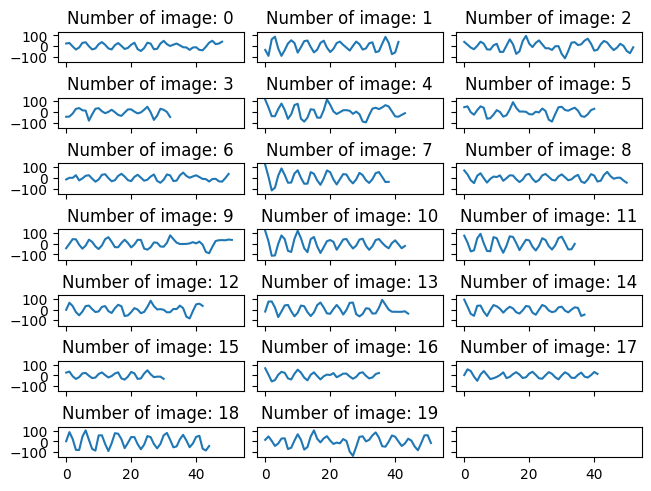

In [29]:
lines_flt = lines.filter_low_frq(inplace=False, nl=2)
lines_flt.plot()

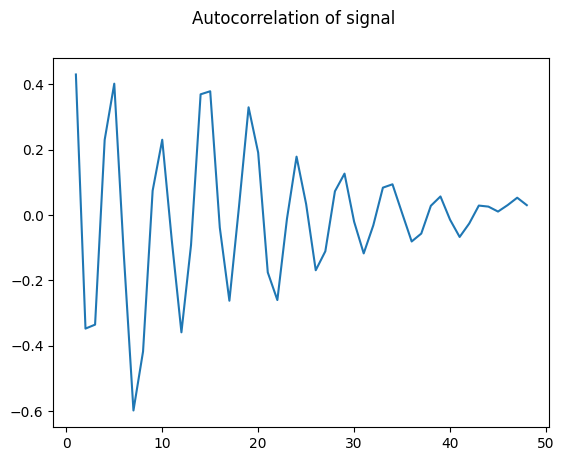

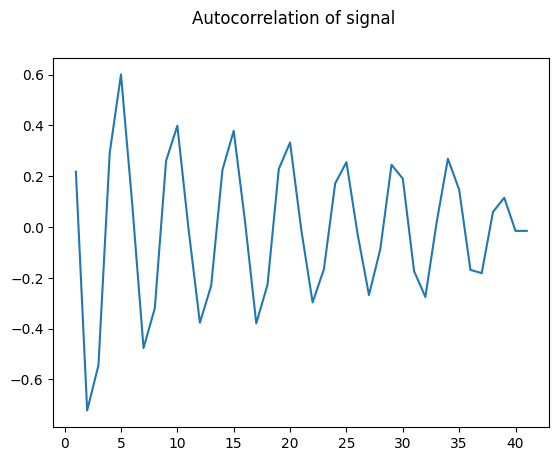

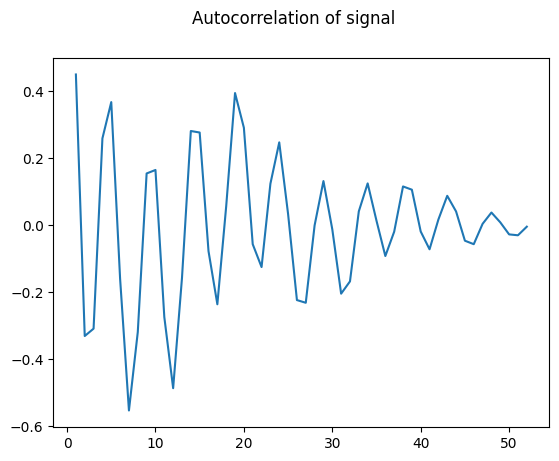

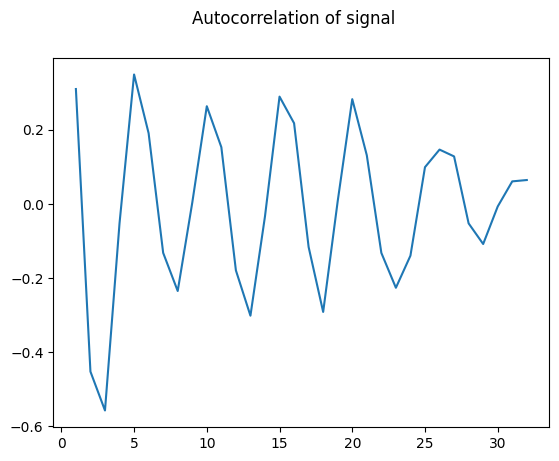

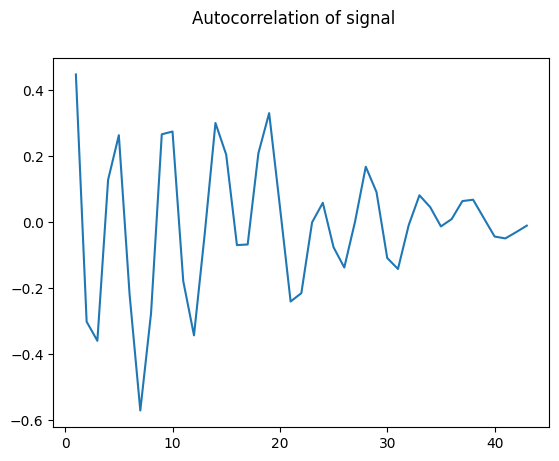

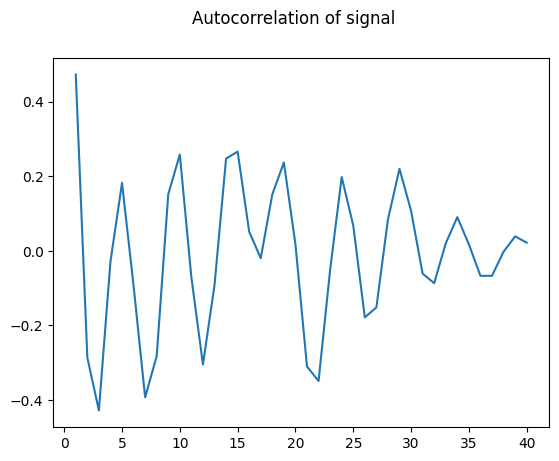

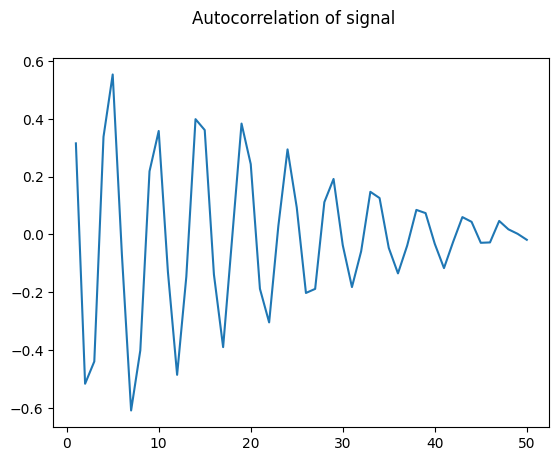

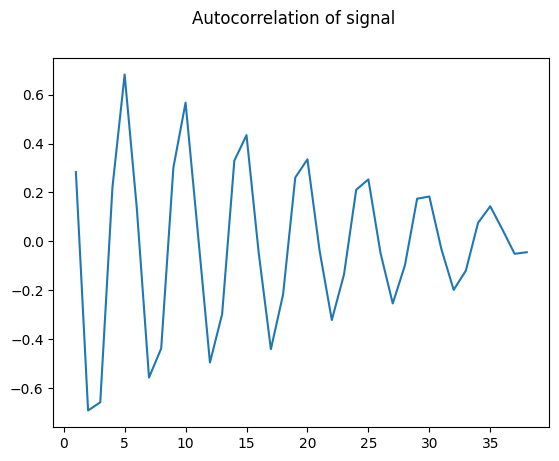

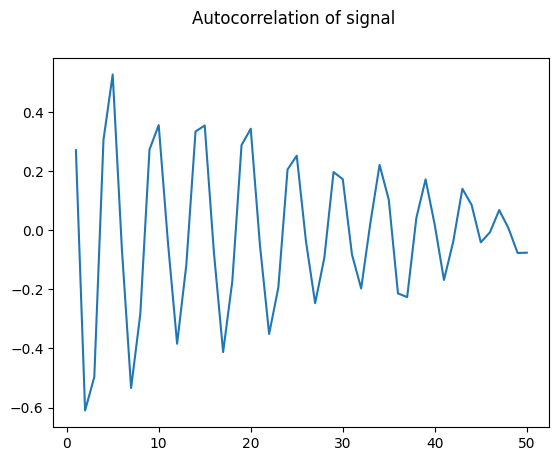

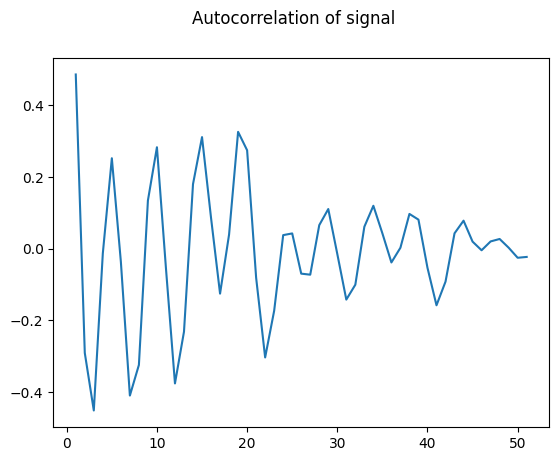

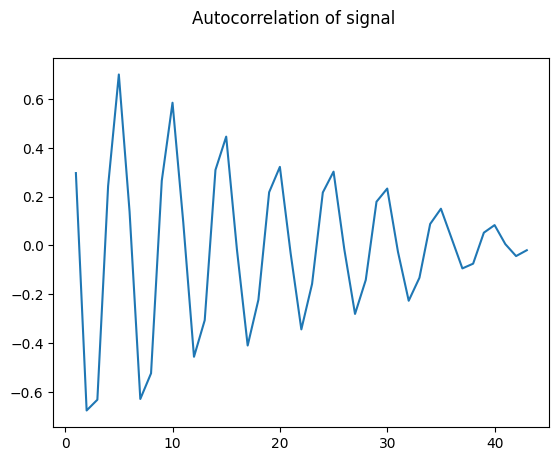

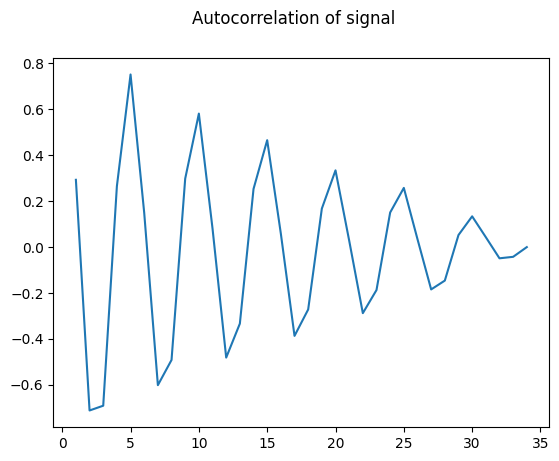

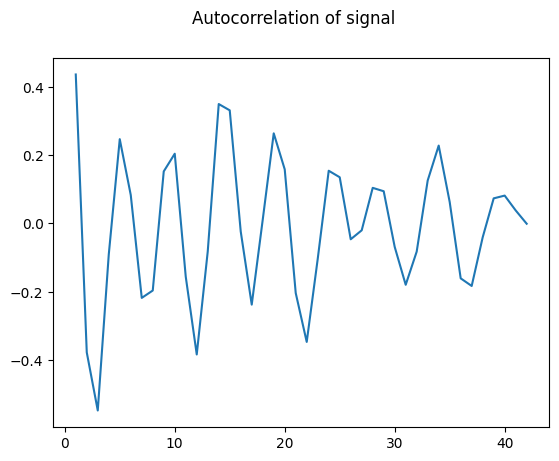

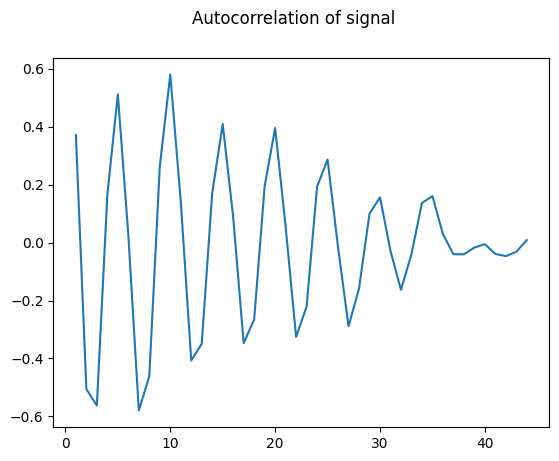

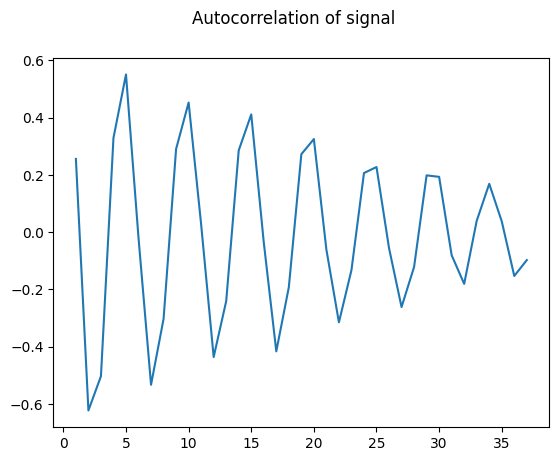

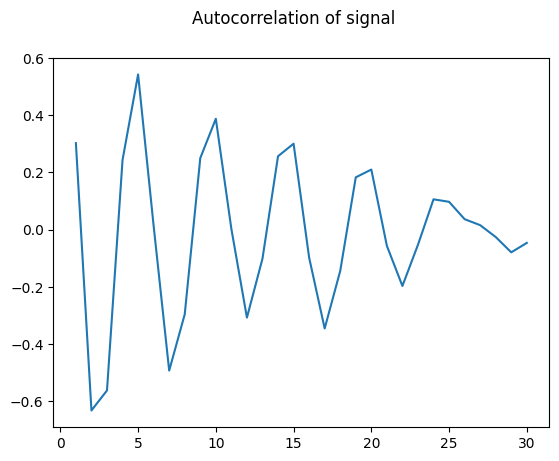

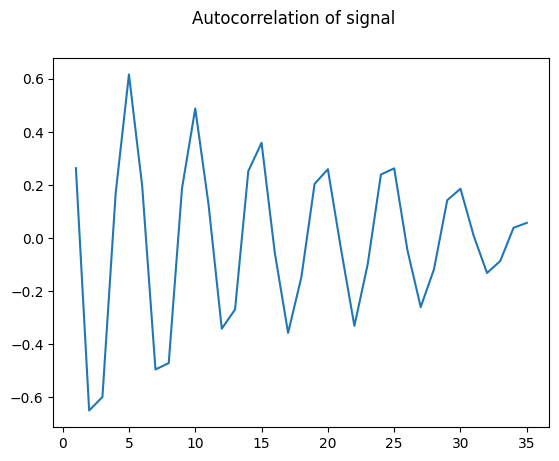

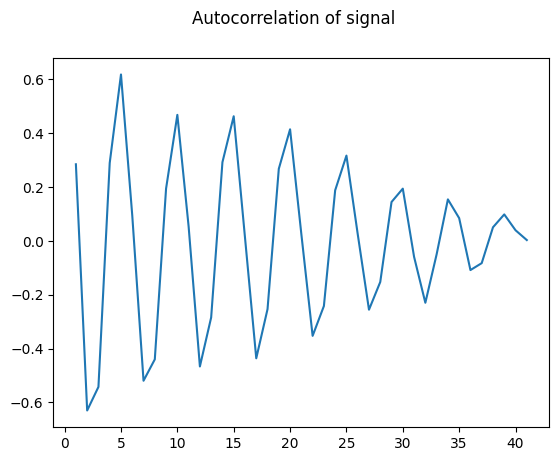

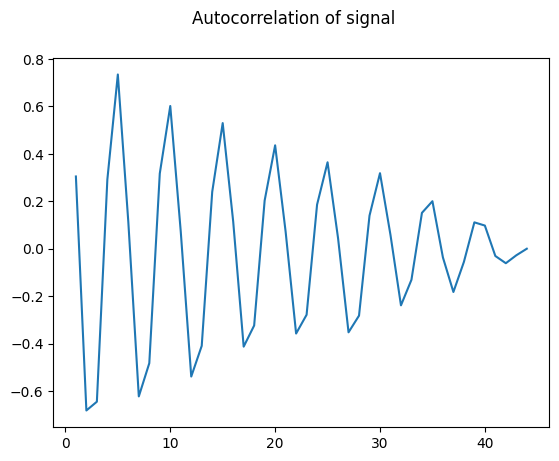

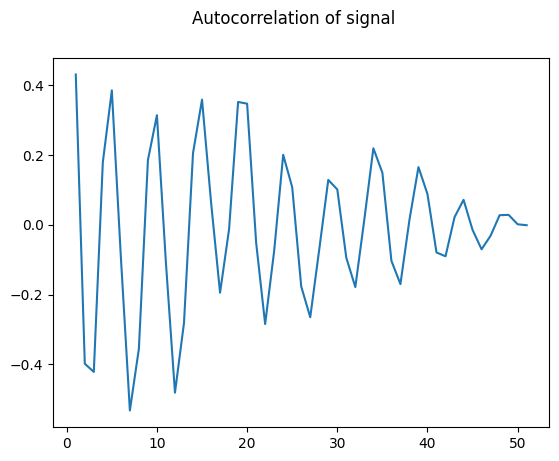

[10, 8, 10, 5, 8, 8, 10, 7, 10, 10, 8, 6, 8, 8, 7, 5, 6, 8, 8, 10]


In [30]:
num_peaks = lines_flt.count_peaks_of_autocorr(show=True)
print(num_peaks)

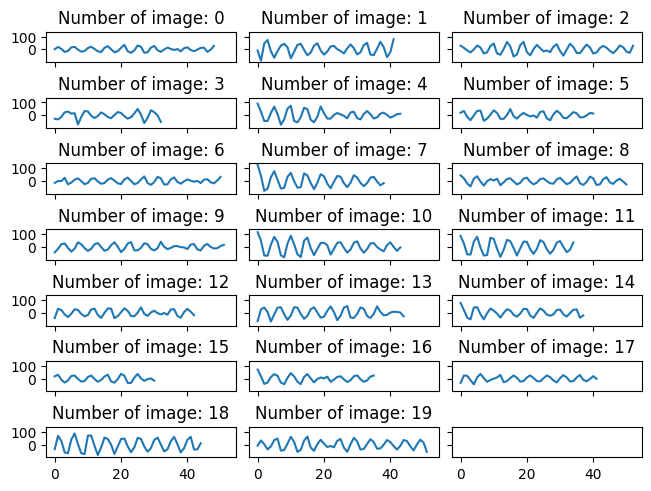

In [31]:
num = [i-1 for i in num_peaks]
lines_flt.filter_low_frq(nl=num)
lines_flt.plot()

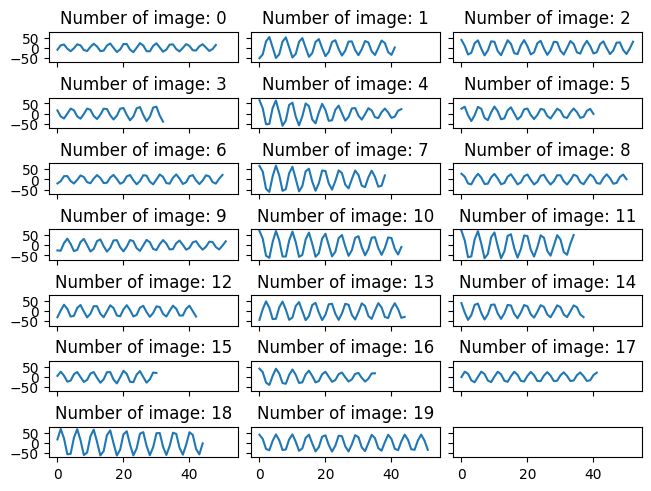

In [32]:
lines_Wn = lines_flt.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
lines_Wn.plot()

In [33]:
frqs = lines_Wn.get_frq(prefilter=False)
print(f"mean frequency: {np.mean(frqs)} --- deviation: {np.std(frqs)}")
print(frqs)

mean frequency: 1.2933806843521254 --- deviation: 0.02492811473626383
[np.float64(1.3369086756087996), np.float64(1.2729591834060674), np.float64(1.3197644090242089), np.float64(1.234388247564999), np.float64(1.3240834306557148), np.float64(1.3123645156233616), np.float64(1.3171302122025905), np.float64(1.2989686205005666), np.float64(1.287705406224561), np.float64(1.298851812510131), np.float64(1.2777069765257643), np.float64(1.2861554820826364), np.float64(1.328883035453248), np.float64(1.287856533210952), np.float64(1.2672006970380083), np.float64(1.3119545396857897), np.float64(1.2759200828828723), np.float64(1.2660383442965475), np.float64(1.2781877538522644), np.float64(1.2845857286934237)]


10
8
10
5
8
8
10
7
10
10
8
6
8
8
7
5
6
8
8
10


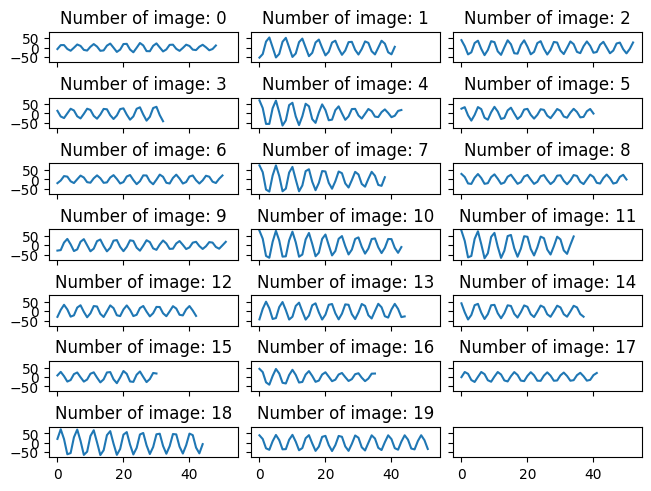

In [34]:
lines_flt = lines.filter(inplace=False, rel_h=0.6, nperseg_c=1)
lines_flt.plot()

In [35]:
init_guess_w = lines_Wn.get_frq(prefilter=False)
lines_flt.get_frq_cos(init_guess_w=init_guess_w)

[np.float64(1.3339544646755315),
 np.float64(1.2760302099317684),
 np.float64(1.317760574020197),
 np.float64(1.237743027317313),
 np.float64(1.3299521338285611),
 np.float64(1.3131543528318417),
 np.float64(1.3160091238119471),
 np.float64(1.292236125564176),
 np.float64(1.2888069329221272),
 np.float64(1.297502724192848),
 np.float64(1.2767982768803605),
 np.float64(1.2851396526506023),
 np.float64(1.3244855642538251),
 np.float64(1.2869287009501404),
 np.float64(1.2718617875885112),
 np.float64(1.3166465412422734),
 np.float64(1.2821771023067712),
 np.float64(1.0521354920351231),
 np.float64(0.9221641714090267),
 np.float64(1.286571516897567)]

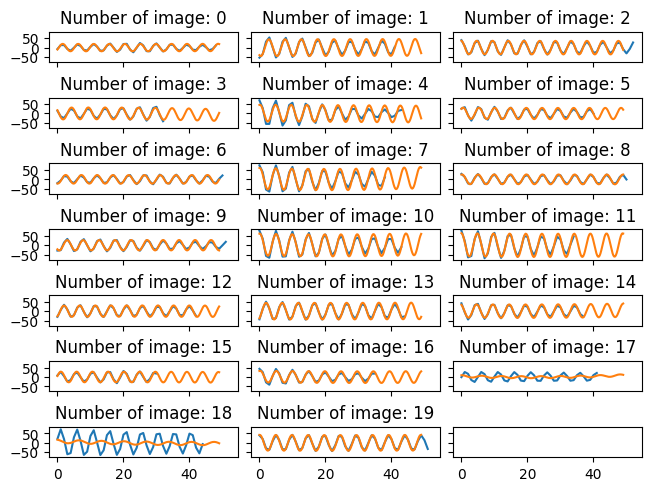

In [36]:
lines_flt.plot(show_cos=True)

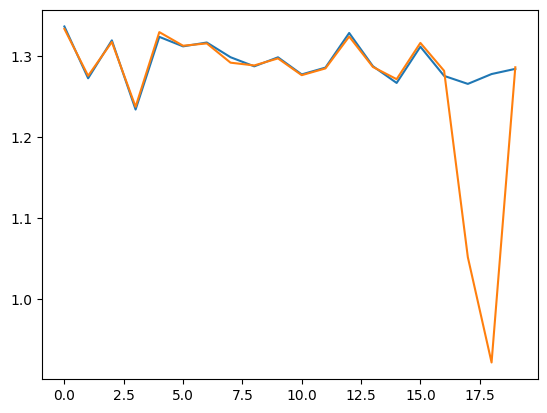

In [37]:
img_number = np.arange(14)

plt.figure()
plt.plot(lines_Wn.frq_list)
plt.plot(lines_flt.frq_cos_list)
plt.show()